# 4. Modelamiento de Datos

**Objetivo del notebook:** construir y comparar modelos de clasificación para predecir el **churn** (abandono) de clientes de una empresa de telecomunicaciones (dataset *Telco Customer Churn*), a partir de los datos ya limpios y transformados en los módulos anteriores.

En este notebook se realiza:
1. Separación de variables predictoras (`X`) y variable objetivo (`y`).
2. Partición de datos en entrenamiento y prueba (train/test), con estratificación.
3. Escalamiento de variables numéricas.
4. Entrenamiento y comparación de tres algoritmos: Regresión Logística, Árbol de Decisión y Random Forest.
5. Evaluación con métricas de clasificación, matriz de confusión y curva ROC.
6. Selección del mejor modelo, prueba con un cliente individual y persistencia de artefactos para reutilización.

In [1]:
# Plomería del entorno (no es parte del análisis): se fija la versión de
# scikit-learn. Los modelos serializados en ../models/*.pkl se guardaron con la
# 1.9.0, y joblib.load() advierte o falla al abrirlos con una versión distinta.
# %pip install -q scikit-learn==1.9.0

# import sklearn
# print("scikit-learn:", sklearn.__version__)
# if sklearn.__version__ != "1.9.0":
#     print("Versión distinta a la esperada (1.9.0).")
#     print("En Colab: menú Entorno de ejecución > Reiniciar sesión, y ejecuta de nuevo esta celda.")

In [2]:
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

## cargar librerias de visualizacion
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

Se importan las librerías de manipulación de datos (`pandas`), visualización (`seaborn`, `matplotlib`) y modelado (`scikit-learn`): algoritmos de clasificación, métricas de evaluación y validación cruzada.

### Parámetros del experimento

Se centralizan aquí los parámetros que controlan el resto del notebook:

- **`metric`**: métrica usada para elegir el mejor modelo (`roc_auc`).
- **`target`**: nombre de la variable objetivo a predecir (`churn`).
- **`alias_model`**: alias corto para cada modelo (`LS`, `DT`, `RF`), usado más adelante para nombrar   de forma compacta las columnas de predicción de los tres modelos en el Excel exportado — evita   columnas como `LogisticRegression_pred`, `DecisionTree_pred`, etc.

In [3]:
metric = "roc_auc"
target = "churn"
alias_model = {"LogisticRegression":"LS", "DecisionTree":"DT", "RandomForest":"RF"}

### Cargar datos

Se lee el dataset preprocesado (salida del módulo de transformación de datos) y se define `customerID` como índice, ya que es un identificador único del cliente y no debe usarse como variable predictora.

In [4]:
fName = "../data/preprocessed_data.csv"
data = pd.read_csv(
                    fName
                    , sep=",", na_values=[""," ","-","NA"]
                )
data.set_index("customerID", inplace=True)
print(f"Datos cargados desde {fName} con shape={data.shape}")
data.head()

Datos cargados desde ../data/preprocessed_data.csv con shape=(7043, 25)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn
customerID,,,,,,,,,,,,,,,,,,,,,,,,,
7590-VHVEG,1,0,1,0,1,0,0,0,1,0,0,0,0,1,29.85,1,0,1,0,0,0,0,1,0,0
5575-GNVDE,0,0,0,0,34,1,0,1,0,1,0,0,0,0,56.95,1,0,0,1,0,0,0,0,1,0
3668-QPYBK,0,0,0,0,2,1,0,1,1,0,0,0,0,1,53.85,1,0,1,0,0,0,0,0,1,1
7795-CFOCW,0,0,0,0,45,0,0,1,0,1,1,0,0,0,42.30,1,0,0,1,0,1,0,0,0,0
9237-HQITU,1,0,0,0,2,1,0,0,0,0,0,0,0,1,70.70,0,1,1,0,0,0,0,1,0,1


### Separación de variables predictoras (`X`) y variable objetivo (`y`)

Se define el conjunto de variables predictoras (`feat`) excluyendo la variable objetivo, y luego se construyen `X` (predictoras) y `y` (objetivo: si el cliente hizo churn o no).

In [6]:
## Separación de variables predictoras y variable objetivo
feat    = [col for col in data.columns if col != target]
print("El numero de variables predictoras es:", len(feat))

El numero de variables predictoras es: 24


In [7]:
X = data[feat]
y = data[target]
print(f"{X.shape=}, {y.shape=}")

X.shape=(7043, 24), y.shape=(7043,)


## Partición en entrenamiento y prueba

Se divide el dataset en dos subconjuntos:
- **Train (80%)**: usado para entrenar los modelos.
- **Test (20%)**: usado únicamente para evaluar el desempeño con datos que el modelo no vio durante el   entrenamiento, simulando el comportamiento en producción.

Se fija `random_state=123` para garantizar que la partición sea reproducible.

In [8]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=123)

print("Train:", X_train.shape, " - Test :", X_test.shape)
print("Distribución de clases en `y_train`=", (y_train.value_counts(normalize=True)*100).round(1).to_dict())
print("Distribución de clases en `y_test`= ", (y_test.value_counts(normalize=True)*100).round(1).to_dict())

Train: (5634, 24)  - Test : (1409, 24)
Distribución de clases en `y_train`= {0: 73.8, 1: 26.2}
Distribución de clases en `y_test`=  {0: 72.0, 1: 28.0}


### ¿Por qué estratificar?

En la partición anterior, la proporción de clientes con y sin churn puede variar levemente entre `train` y `test` por simple azar. Al usar `stratify=y`, se obliga a que ambos subconjuntos conserven la **misma proporción de clases** que el dataset original. Esto es especialmente importante en problemas con clases desbalanceadas, porque evita que el conjunto de prueba quede con muy pocos casos positivos (churn) para evaluar el modelo de forma confiable.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
                                                    X, y, test_size=0.20, random_state=123
                                                    , stratify=y
                                                )

print("Train:", X_train.shape, " - Test :", X_test.shape)
print("Distribución de clases en `y_train`=", (y_train.value_counts(normalize=True)*100).round(1).to_dict())
print("Distribución de clases en `y_test`= ", (y_test.value_counts(normalize=True)*100).round(1).to_dict())

Train: (5634, 24)  - Test : (1409, 24)
Distribución de clases en `y_train`= {0: 73.5, 1: 26.5}
Distribución de clases en `y_test`=  {0: 73.5, 1: 26.5}


# Escalamiento de datos

Solo las variables numéricas continuas (`tenure` y `monthlycharges`) requieren escalamiento; las variables categóricas ya fueron codificadas en el módulo de preprocesamiento previo.

**¿Por qué escalar?** Modelos basados en distancias o gradientes —como la Regresión Logística— son sensibles a la escala de las variables: una variable con rango mucho mayor puede dominar el cálculo del modelo aunque no sea más relevante. Los modelos basados en árboles (Decision Tree, Random Forest) son invariantes a la escala, por lo que **no** requieren este paso; por eso más adelante solo se usa la versión escalada (`X_train_scaled`, `X_test_scaled`) para la Regresión Logística.

In [14]:
num_feat = ["tenure", "monthlycharges"]
data[num_feat].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.0,29.00,55.00,72.00
monthlycharges,7043.0,64.761692,30.090047,18.25,35.5,70.35,89.85,118.75


In [15]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
print("Train:", X_train_scaled.shape, " - Test :", X_test_scaled.shape)

Train: (5634, 24)  - Test : (1409, 24)


Se ajusta (`fit`) el escalador **únicamente con `X_train`** y luego se aplica (`transform`) tanto a train como a test. Ajustar el escalador con todo el dataset (incluyendo test) produciría **fuga de información (data leakage)**, ya que el modelo tendría indirectamente acceso a estadísticas del conjunto de prueba.

In [16]:
scaler = StandardScaler()
# scaler = MinMaxScaler()

X_train_scaled[num_feat] = scaler.fit_transform(X_train[num_feat])
X_test_scaled[num_feat]  = scaler.transform(X_test[num_feat])

X_train_scaled[num_feat].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,5634.0,-1.071994e-16,1.000089,-1.313101,-0.946056,-0.130398,0.929957,1.623266
monthlycharges,5634.0,2.522338e-18,1.000089,-1.545087,-0.971536,0.187645,0.835754,1.803751


# Modelos de Machine Learning

Se entrenan y comparan tres algoritmos de clasificación con enfoques distintos, para contrastar desempeño e interpretabilidad:

| Modelo | Tipo | Característica clave |
|---|---|---|
| Regresión Logística | Lineal | Interpretable, requiere variables escaladas |
| Decision Tree | Basado en árboles | Interpretable visualmente, propenso a sobreajuste |
| Random Forest | Ensamble de árboles | Mayor robustez y desempeño, permite importancia de variables |

El enfoque es de **benchmarking** (comparación con hiperparámetros razonables por defecto), no de ajuste exhaustivo de hiperparámetros — ese paso queda para una fase posterior de optimización.

In [17]:
models = {
        "LogisticRegression": LogisticRegression(max_iter=1000, random_state=123),
        "DecisionTree": DecisionTreeClassifier(random_state=123),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=123)
    }

### Entrenamiento y métricas sobre `train`

Se entrena cada modelo con su conjunto correspondiente (escalado para Regresión Logística, original para los modelos basados en árboles) y se calculan las métricas sobre los **mismos datos de entrenamiento**. Este resultado sirve como referencia de cuánto "aprendió" cada modelo del pasado, pero **no** debe usarse para decidir cuál es mejor — para eso se necesita el desempeño en `test` y la validación cruzada.

In [18]:
train_metrics = []
train_predictions = dict()

for name, model in models.items():
    X_ = X_train_scaled if name=="LogisticRegression" else X_train
    model.fit(X_, y_train)
    y_pred = model.predict(X_)
    y_prob = model.predict_proba(X_)[:, 1]
    train_metrics.append({
        "model": name,
        "accuracy": accuracy_score(y_train, y_pred),
        "precision": precision_score(y_train, y_pred),
        "recall": recall_score(y_train, y_pred),
        "f1": f1_score(y_train, y_pred),
        "roc_auc": roc_auc_score(y_train, y_prob)
    })
    train_predictions[name] = {"pred":y_pred, "prob":y_prob}
train_metrics = pd.DataFrame(train_metrics).set_index("model")

models

{'LogisticRegression': LogisticRegression(max_iter=1000, random_state=123),
 'DecisionTree': DecisionTreeClassifier(random_state=123),
 'RandomForest': RandomForestClassifier(n_estimators=200, random_state=123)}

In [19]:
print("Metricas de entrenamiento:")
train_metrics

Metricas de entrenamiento:


,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.804579,0.658106,0.548495,0.598322,0.846351
DecisionTree,0.997515,0.999326,0.991304,0.995299,0.999984
RandomForest,0.997515,0.995318,0.995318,0.995318,0.999956


In [20]:
train_predictions

{'LogisticRegression': {'pred': array([0, 1, 0, ..., 1, 0, 0], shape=(5634,)),
  'prob': array([0.01213108, 0.70363769, 0.00773874, ..., 0.51854179, 0.13989029,
         0.45418868], shape=(5634,))},
 'DecisionTree': {'pred': array([0, 1, 0, ..., 1, 0, 0], shape=(5634,)),
  'prob': array([0., 1., 0., ..., 1., 0., 0.], shape=(5634,))},
 'RandomForest': {'pred': array([0, 1, 0, ..., 1, 0, 0], shape=(5634,)),
  'prob': array([0.   , 0.95 , 0.   , ..., 0.84 , 0.055, 0.08 ], shape=(5634,))}}

### Validación Cruzada (Cross Validation - CV)

Evaluar un modelo con una sola partición train/test puede dar una estimación optimista o pesimista por azar. La validación cruzada (`cv=5`) entrena y evalúa el modelo 5 veces sobre distintos subconjuntos de `train`, y reporta la media y desviación estándar de la métrica (`roc_auc`). Esto da una estimación más robusta y estable del desempeño esperado, y permite detectar modelos con alta varianza entre folds.

In [21]:
cv_scores = dict()

for name, model in models.items():
    X_ = X_train_scaled if name=="LogisticRegression" else X_train
    cv_scores[name] = cross_val_score(
            model,
            X_,
            y_train,
            cv=5,
            scoring="roc_auc",
        )
cv_scores = dict((k,{"mean": sco.mean(), "std": sco.std(), "folds": sco}) for k, sco in cv_scores.items())
cv_scores = pd.DataFrame.from_dict(cv_scores, orient="index")
cv_scores

,mean,std,folds
LogisticRegression,0.843316,0.011055,"[0.8297909295073758, 0.8427285799686555, 0.843..."
DecisionTree,0.657586,0.017218,"[0.6259997091755125, 0.6525455221107395, 0.671..."
RandomForest,0.824236,0.016276,"[0.794338616644855, 0.8306492656681692, 0.8238..."


### Evaluar desempeño con el conjunto de `test`

Esta es la evaluación que realmente importa: mide cómo se comporta cada modelo con datos que **no** vio durante el entrenamiento.

| Métrica | Interpretación en el contexto de churn |
|---|---|
| **Accuracy** | Porcentaje total de aciertos (puede ser engañosa si las clases están desbalanceadas) |
| **Precision** | De los clientes predichos como churn, cuántos realmente abandonan |
| **Recall** | De los clientes que realmente abandonan, cuántos detecta el modelo |
| **F1** | Balance entre precision y recall |
| **ROC-AUC** | Capacidad general del modelo para discriminar entre churn y no churn |


> En un caso de negocio como retención de clientes, suele priorizarse **Recall** (no dejar pasar clientes que sí van a abandonar) sobre Accuracy, aunque la elección depende del costo de cada tipo de error.

In [22]:
test_metrics = []
test_predictions = dict()

for name, model in models.items():
    X_ = X_test_scaled if name == "LogisticRegression" else X_test
    y_pred = model.predict(X_)
    y_prob = model.predict_proba(X_)[:, 1]
    test_metrics.append({
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_prob)
    })
    test_predictions[name] = {"pred":y_pred, "prob":y_prob}
test_metrics = pd.DataFrame(test_metrics).set_index("model")

test_metrics

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.800568,0.653465,0.529412,0.584934,0.843452
DecisionTree,0.728176,0.488127,0.494652,0.491368,0.656741
RandomForest,0.787793,0.624585,0.502674,0.557037,0.813078


In [23]:
test_predictions

{'LogisticRegression': {'pred': array([0, 0, 0, ..., 0, 0, 0], shape=(1409,)),
  'prob': array([0.00951451, 0.15661204, 0.032859  , ..., 0.00509873, 0.1538585 ,
         0.41700294], shape=(1409,))},
 'DecisionTree': {'pred': array([0, 0, 0, ..., 0, 0, 0], shape=(1409,)),
  'prob': array([0., 0., 0., ..., 0., 0., 0.], shape=(1409,))},
 'RandomForest': {'pred': array([0, 0, 0, ..., 0, 0, 0], shape=(1409,)),
  'prob': array([0.   , 0.21 , 0.02 , ..., 0.1  , 0.015, 0.44 ], shape=(1409,))}}

### Resultados obtenidos hasta el momento

Se compara la métrica `roc_auc` en tres escenarios: `train` (desempeño sobre datos ya vistos), `cv_train` (promedio de validación cruzada, más confiable) y `test` (desempeño con datos nuevos). Una brecha grande entre `train` y `test`/`cv_train` es señal de sobreajuste (overfitting).

In [24]:
print("Comparacion de [roc_auc] del `train` vs `cv train` vs `test`:")
pd.DataFrame({
                "train": train_metrics["roc_auc"].values
                , "cv_train": cv_scores["mean"].values
                , "test": test_metrics["roc_auc"].values
                }, index=train_metrics.index)

Comparacion de [roc_auc] del `train` vs `cv train` vs `test`:


,train,cv_train,test
model,,,
LogisticRegression,0.846351,0.843316,0.843452
DecisionTree,0.999984,0.657586,0.656741
RandomForest,0.999956,0.824236,0.813078


Se revisan las clases aprendidas por cada modelo (`0` = No Churn, `1` = Churn) y se define un diccionario de mapeo para presentar los resultados con etiquetas legibles en los gráficos siguientes.

In [25]:
dict((name,model.classes_) for name,model in models.items())

{'LogisticRegression': array([0, 1]),
 'DecisionTree': array([0, 1]),
 'RandomForest': array([0, 1])}

In [26]:
clases_map = {"0": "No Churn", "1": "Churn"}
clases_map

{'0': 'No Churn', '1': 'Churn'}

## Matriz de confusión

La matriz de confusión desagrega los aciertos y errores de cada modelo en cuatro categorías, interpretadas aquí en el contexto de retención de clientes:

- **TP (Verdadero Positivo)**: el cliente iba a abandonar y el modelo lo detectó → se puede intervenir a tiempo.
- **TN (Verdadero Negativo)**: el cliente se queda y el modelo lo predijo correctamente.
- **FP (Falso Positivo)**: el modelo predice churn, pero el cliente se queda → costo de una intervención innecesaria.
- **FN (Falso Negativo)**: el cliente abandona pero el modelo no lo detectó → el error más costoso, se pierde al cliente sin intervención.

Además de los conteos, se calculan las tasas TPR, TNR, FPR y FNR para comparar el comportamiento relativo de los modelos, independiente del tamaño de cada clase.

In [27]:
c_matrix = dict()

for name, pred in test_predictions.items():
    c_matrix[name] = {"confusion_matrix": confusion_matrix(y_test, pred["pred"])}
    tn, fp, fn, tp = c_matrix[name]["confusion_matrix"].ravel()
    c_matrix[name].update({"tn":tn, "fp":fp, "fn":fn, "tp":tp})
    total = int(tp + tn + fp + fn)
    c_matrix[name].update({
                        "tpr": (tp / (tp + fn) if (tp + fn) > 0 else 0)
                        , "tnr": (tn / (tn + fp) if (tn + fp) > 0 else 0)
                        , "fpr": (fp / (fp + tn) if (fp + tn) > 0 else 0)
                        , "fnr": (fn / (fn + tp) if (fn + tp) > 0 else 0)
                })
print("Conteos y Ratios:")
pd.DataFrame(c_matrix).iloc[1:]

Conteos y Ratios:


,LogisticRegression,DecisionTree,RandomForest
tn,930,841,922
fp,105,194,113
fn,176,189,186
tp,198,185,188
tpr,0.529412,0.494652,0.502674
tnr,0.898551,0.81256,0.890821
fpr,0.101449,0.18744,0.109179
fnr,0.470588,0.505348,0.497326


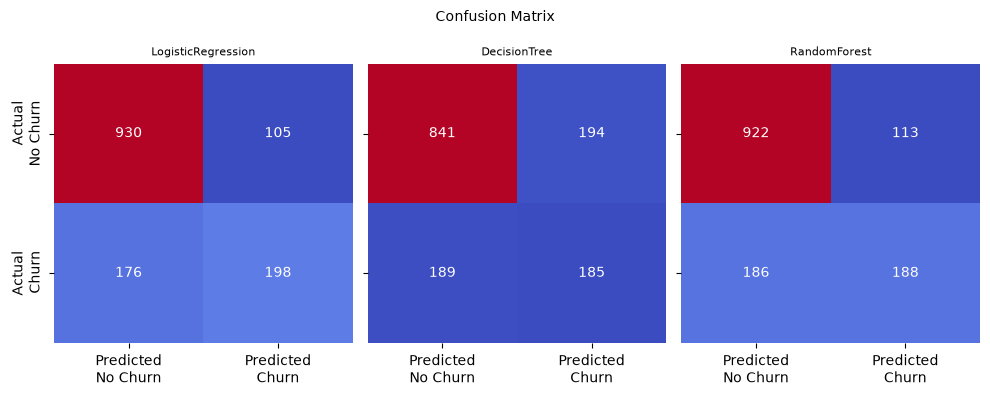

In [28]:
fig, axes = plt.subplots(nrows=1, ncols=len(test_predictions), figsize=(10, 4))
axes = axes.flatten()
for i,name in enumerate(c_matrix):
    sns.heatmap(
                c_matrix[name]["confusion_matrix"]
                , annot=True, fmt="d", cmap="coolwarm", cbar=False
                # , xticklabels=["Predicted\nNo Churn", "Predicted\nChurn"], yticklabels=["Actual\nNo Churn", "Actual\nChurn"]
                , ax=axes[i]
            )
    if i==0:
        axes[i].set_yticklabels(["Actual\nNo Churn", "Actual\nChurn"])
    else:
        axes[i].set_yticklabels("")
    axes[i].set_xticklabels(["Predicted\nNo Churn", "Predicted\nChurn"])
    axes[i].set_title(f"{name}", size=8)
fig.suptitle(f"Confusion Matrix", size=10)
plt.tight_layout()
plt.show()

## Curva ROC-AUC

La curva ROC muestra, para cada posible umbral de decisión, la relación entre la **Tasa de Verdaderos Positivos** (Recall) y la **Tasa de Falsos Positivos**. Cuanto más se acerque la curva a la esquina superior izquierda, mejor discrimina el modelo entre clases. El área bajo la curva (AUC) resume ese desempeño en un solo número: 0.5 equivale a una predicción aleatoria y 1.0 a una separación perfecta.

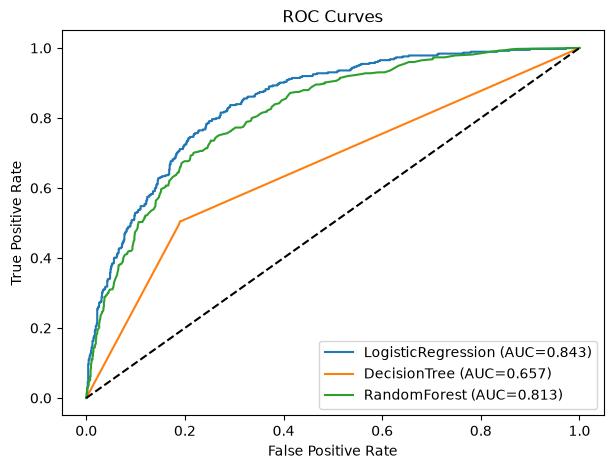

In [29]:
plt.figure(figsize=(7,5))

for name, pred in test_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, pred["prob"])
    auc = roc_auc_score(y_test, pred["prob"])

    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0,1], [0,1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

## Importancia de variables (Feature Importance)

El modelo `Random Forest` permite calcular la importancia de cada variable en función de cuánto reduce la impureza al usarse en las divisiones de sus árboles. Esto ayuda a entender **qué factores están más asociados al churn** y es un insumo valioso para el negocio, más allá del desempeño predictivo.

In [30]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": models["RandomForest"].feature_importances_
}).sort_values("importance", ascending=False)

importance.set_index("feature").head(15).style.format("{:.2%}")

,importance
feature,
monthlycharges,22.75%
tenure,22.16%
contract_month-to-month,6.20%
internetservice_fiber optic,4.29%
gender,3.41%
paymentmethod_electronic check,3.24%
paperlessbilling,3.05%
partner,2.83%
contract_two year,2.82%


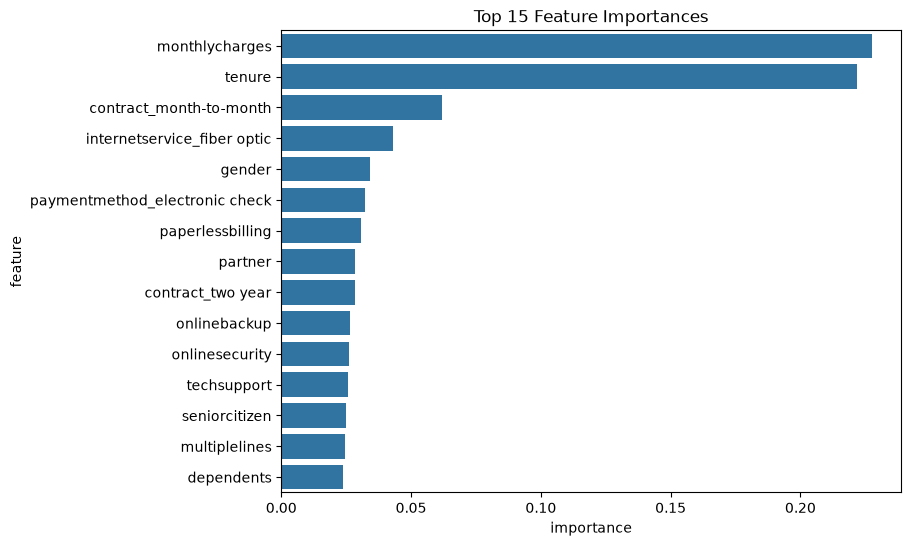

In [31]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=importance.head(15),
    x="importance",
    y="feature"
)
plt.title("Top 15 Feature Importances")
plt.show()

# Selección del modelo con mejor desempeño

Se consolidan las métricas de `train` y `test` de los tres modelos en una sola tabla para facilitar la comparación lado a lado.

In [32]:
cols_metrics = [l for lst in [[c+"_train", c+"_test"] for c in train_metrics] for l in lst]
metrics = pd.concat([
            train_metrics.add_suffix("_train")
            , test_metrics.add_suffix("_test")
        ], axis=1)[cols_metrics]
metrics

,accuracy_train,accuracy_test,precision_train,precision_test,recall_train,recall_test,f1_train,f1_test,roc_auc_train,roc_auc_test
model,,,,,,,,,,
LogisticRegression,0.804579,0.800568,0.658106,0.653465,0.548495,0.529412,0.598322,0.584934,0.846351,0.843452
DecisionTree,0.997515,0.728176,0.999326,0.488127,0.991304,0.494652,0.995299,0.491368,0.999984,0.656741
RandomForest,0.997515,0.787793,0.995318,0.624585,0.995318,0.502674,0.995318,0.557037,0.999956,0.813078


### Preguntas guía para elegir el modelo

Antes de declarar un ganador solo por la métrica más alta, conviene responder:

- ¿Qué tan bien aprende el modelo el pasado (desempeño en `train`)?
- ¿Qué tan bien funciona con casos nuevos (desempeño en `test` / CV)?
- ¿Qué tipo de errores comete (FP vs FN, según la matriz de confusión)?
- ¿Cuál elegiríamos para tomar decisiones reales, considerando también interpretabilidad y estabilidad?

El modelo ganador se selecciona de forma automática ordenando por la métrica definida en el parámetro `metric` (`roc_auc`) sobre el conjunto de `test`, y se guarda su nombre en `best_model_name` para reutilizarlo en el resto del notebook.

In [33]:
test_metrics.sort_values(metric, ascending=False)

,accuracy,precision,recall,f1,roc_auc
model,,,,,
LogisticRegression,0.800568,0.653465,0.529412,0.584934,0.843452
RandomForest,0.787793,0.624585,0.502674,0.557037,0.813078
DecisionTree,0.728176,0.488127,0.494652,0.491368,0.656741


In [34]:
best_model_name = test_metrics.sort_values(metric, ascending=False).iloc[0].name
print(f"El mejor modelo segun CV[{metric}] es [{best_model_name}]")
models[best_model_name]

El mejor modelo segun CV[roc_auc] es [LogisticRegression]


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",123
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'l

In [35]:
test_predictions[best_model_name]

{'pred': array([0, 0, 0, ..., 0, 0, 0], shape=(1409,)),
 'prob': array([0.00951451, 0.15661204, 0.032859  , ..., 0.00509873, 0.1538585 ,
        0.41700294], shape=(1409,))}

### Consolidar predicciones de train y test

Se construye un dataset único (`data_`) que combina las variables originales con las predicciones de **los tres modelos** (no solo el ganador), usando `alias_model` para prefijar cada columna (`LS_pred`, `LS_prob`, `DT_pred`, `DT_prob`, `RF_pred`, `RF_prob`) — así el equipo de negocio puede comparar los tres modelos lado a lado en el mismo archivo, en lugar de ver solo la predicción del modelo que ganó en este notebook. También se agrega una columna `split` que identifica el origen (`train`/`test`) de cada registro.

**No necesitas entender el código de las dos celdas siguientes en detalle** — son celdas de "plomería" (reorganizar y unir tablas con `pandas`), no aportan un concepto nuevo de modelamiento. Lo que importa es el resultado: un Excel con las predicciones de los 3 modelos, listo para revisar o llevar a Power BI.

In [36]:
## datasset original con identificación de separacion en train y test
data_ = pd.concat([pd.concat([X_train, y_train], axis=1), pd.concat([X_test, y_test], axis=1)], axis=0)
data_["split"] = ["train" if a==True else "test" for a in data_.index.isin(X_train.index)]
data_

,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn,split
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,
5605-XNWEN,0,1,1,0,72,1,1,0,0,0,0,0,0,1,25.00,0,0,0,0,1,1,0,0,0,0,train
7409-KIUTL,1,1,0,1,1,1,0,0,0,0,0,0,0,1,71.00,0,1,1,0,0,0,0,1,0,1,train
0971-QIFJK,1,0,1,0,69,1,1,0,0,0,0,0,0,0,24.25,0,0,0,0,1,1,0,0,0,0,train
2675-DHUTR,0,1,1,0,58,1,1,0,1,0,0,1,1,1,98.90,0,1,1,0,0,0,0,1,0,0,train
5201-FRKKS,0,0,0,0,25,1,0,1,0,0,0,0,0,0,74.30,0,1,1,0,0,1,0,0,0,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7851-WZEKY,1,0,0,0,2,1,1,0,0,0,0,1,1,1,95.15,0,1,1,0,0,0,0,1,0,1,test
0616-ATFGB,0,1,1,0,1,0,0,0,0,0,0,0,0,0,25.05,1,0,1,0,0,0,0,1,0,1,test
7169-YWAMK,0,0,1,1,72,1,0,1,1,0,1,1,0,0,68.40,1,0,0,0,1,1,0,0,0,0,test


In [37]:
## agregando resultados de predicciones
data_ = pd.concat([
            data_
            , pd.concat([
                    pd.concat(
                                list(pd.DataFrame(train_predictions[name]).add_prefix(alias+"_") for name,alias in alias_model.items())
                                , axis=1
                            ).set_index(X_train.index)
                    , pd.concat(
                                list(pd.DataFrame(test_predictions[name]).add_prefix(alias+"_") for name,alias in alias_model.items())
                                , axis=1
                            ).set_index(X_test.index)
                    ]
                , axis=0
            )
            ]
        , axis=1)
print(f"{data_.shape=}")
data_

data_.shape=(7043, 32)


,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,onlinesecurity,onlinebackup,deviceprotection,techsupport,streamingtv,streamingmovies,paperlessbilling,monthlycharges,internetservice_dsl,internetservice_fiber optic,contract_month-to-month,contract_one year,contract_two year,paymentmethod_bank transfer (automatic),paymentmethod_credit card (automatic),paymentmethod_electronic check,paymentmethod_mailed check,churn,split,LS_pred,LS_prob,DT_pred,DT_prob,RF_pred,RF_prob
customerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5605-XNWEN,0,1,1,0,72,1,1,0,0,0,0,0,0,1,25.00,0,0,0,0,1,1,0,0,0,0,train,0,0.012131,0,0.0,0,0.000
7409-KIUTL,1,1,0,1,1,1,0,0,0,0,0,0,0,1,71.00,0,1,1,0,0,0,0,1,0,1,train,1,0.703638,1,1.0,1,0.950
0971-QIFJK,1,0,1,0,69,1,1,0,0,0,0,0,0,0,24.25,0,0,0,0,1,1,0,0,0,0,train,0,0.007739,0,0.0,0,0.000
2675-DHUTR,0,1,1,0,58,1,1,0,1,0,0,1,1,1,98.90,0,1,1,0,0,0,0,1,0,0,train,0,0.474156,0,0.0,0,0.215
5201-FRKKS,0,0,0,0,25,1,0,1,0,0,0,0,0,0,74.30,0,1,1,0,0,1,0,0,0,0,train,0,0.282805,0,0.0,0,0.060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7851-WZEKY,1,0,0,0,2,1,1,0,0,0,0,1,1,1,95.15,0,1,1,0,0,0,0,1,0,1,test,1,0.837210,1,1.0,1,0.975
0616-ATFGB,0,1,1,0,1,0,0,0,0,0,0,0,0,0,25.05,1,0,1,0,0,0,0,1,0,1,test,1,0.549594,1,1.0,1,0.685
7169-YWAMK,0,0,1,1,72,1,0,1,1,0,1,1,0,0,68.40,1,0,0,0,1,1,0,0,0,0,test,0,0.005099,0,0.0,0,0.100


Se exporta el resultado a Excel para que pueda ser consumido por áreas de negocio o cargado en una herramienta de BI (por ejemplo, Power BI) sin depender de Python.

In [38]:
fName = "../output/Telco-Customer-Churn_Resultados.xlsx"
data_.reset_index().to_excel(fName, index=False)
print(fName)

../output/Telco-Customer-Churn_Resultados.xlsx


## Prueba puntual: consultar un solo cliente

Se simula el uso del modelo en un caso real: se busca, dentro de `data_`, un cliente del conjunto de `test` que efectivamente abandonó y que el **modelo ganador** (`best_model_name`) predijo correctamente como churn — usando `alias_model` para construir dinámicamente el nombre de la columna de predicción correspondiente (por ejemplo `RF_pred` si `RandomForest` fue el ganador). Esto valida que el flujo de scoring funciona a nivel de registro individual, como ocurriría en producción.

In [39]:
id_busq = data_[(data_[target]==1) & (data_[[a for m,a in alias_model.items() if m==best_model_name][0]+"_pred"]==1) & (data_["split"]=="test")].index[0]      ## abandono
# id_busq = data_[(data_[target]==0) & (data_[[a for m,a in alias_model.items() if m==best_model_name][0]+"_pred"]==0) & (data_["split"]=="test")].index[0]      ## NO abandono
print(f"{id_busq=}")
new_customer = X_test_scaled.loc[[id_busq]] if best_model_name=="LogisticRegression" else X_test.loc[[id_busq]]
new_customer.T

id_busq='3158-MOERK'


customerID,3158-MOERK
gender,1.000000
seniorcitizen,0.000000
partner,0.000000
dependents,0.000000
tenure,-1.231536
phoneservice,1.000000
multiplelines,1.000000
onlinesecurity,0.000000
onlinebackup,0.000000
deviceprotection,0.000000


In [40]:
print(f"La probabilidad de Churn es de {models[best_model_name].predict_proba(new_customer)[0][1]:.2%}.")

La probabilidad de Churn es de 83.85%.


## Guardar el modelo (persistencia de artefactos)

Guardar los artefactos del experimento permite reutilizar el modelo con nuevos datos sin tener que reentrenar, y facilita la trazabilidad del experimento (qué datos, qué modelo, qué métricas se obtuvieron).

- Es indispensable aplicar exactamente el **mismo preprocesamiento** (escalamiento, codificación,   imputaciones) a cualquier dato nuevo antes de predecir con el modelo cargado.
- Para flujos productivos, se recomienda encapsular preprocesamiento + modelo en un   [`Pipeline` de scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html),   de forma que ambos se guarden y carguen como una sola unidad, evitando inconsistencias.

In [41]:
import joblib

In [42]:
models = dict((name, {"best_model": name==best_model_name, "model": model}) for name, model in models.items())
models

{'LogisticRegression': {'best_model': True,
  'model': LogisticRegression(max_iter=1000, random_state=123)},
 'DecisionTree': {'best_model': False,
  'model': DecisionTreeClassifier(random_state=123)},
 'RandomForest': {'best_model': False,
  'model': RandomForestClassifier(n_estimators=200, random_state=123)}}

Se guardan cuatro artefactos independientes con `joblib`:

1. **`data.pkl`**: particiones de datos (train/test, escaladas y sin escalar), para reproducir el experimento.
2. **`modelos_entrenados.pkl`**: los tres modelos entrenados, marcando cuál fue el mejor.
3. **`metrics.pkl`**: métricas de train, test y matrices de confusión, para auditoría y comparación futura.
4. **`scaler.pkl`**: el escalador ajustado, necesario para transformar nuevos datos antes de predecir con la Regresión Logística.

In [43]:
joblib.dump({
                "X_train":X_train,"y_train":y_train
                ,"X_test":X_test,"y_test":y_test
                , "X_train_scaled":X_train_scaled, "X_test_scaled":X_test_scaled
             }
            , f"../models/data.pkl")
joblib.dump(models, f"../models/modelos_entrenados.pkl")
joblib.dump({"train_metrics": train_metrics, "test_metrics":test_metrics, "confusion_matrix": c_matrix}, f"../models/metrics.pkl")
joblib.dump(scaler, f"../models/scaler.pkl")

print("Data, Modelo, Scaler y Metricas guardadas.")

Data, Modelo, Scaler y Metricas guardadas.


## Conclusiones y siguientes pasos

Este notebook cubrió el ciclo completo de un experimento de clasificación: preparación de datos, partición, escalamiento, entrenamiento comparativo, evaluación y persistencia. El proyecto **no está en fase exploratoria**; el estado actual es de **iteración de modelado / optimización / interpretación**.

Próximos pasos recomendados:

1. **Validación robusta**: ampliar la validación cruzada estratificada y estimar intervalos de confianza de las métricas.
2. **Optimización de hiperparámetros**: `GridSearchCV` o `RandomizedSearchCV` sobre el modelo seleccionado.
3. **Interpretabilidad**: complementar la importancia de variables con `SHAP` o *permutation importance*, y analizar los falsos positivos/negativos.
4. **Operacionalización**: encapsular preprocesamiento + modelo en un `Pipeline`, definir una función `predict()` con validación de esquema de entrada, y versionar el modelo para despliegue.